# 04 - Fold Regime Diagnosis

**Goal:** Diagnose why certain folds fail while others succeed in the Phase 2 walk-forward CV.

**Fold Status (at threshold 0.55):**
- Fold 1: Bad LONG, Bad SHORT
- Fold 2: Good LONG, Good SHORT
- Fold 3: Good LONG, Bad SHORT
- Fold 4: Bad LONG, Good SHORT
- Fold 5: Good LONG, Bad SHORT

**Hypothesis:** Different market regimes (volatility, trend, alignment, persistence) favor different strategies.

**Analysis Steps:**
1. Reconstruct fold boundaries from walk-forward logic
2. Tag rows with fold and performance status
3. Visualize price action across folds
4. Compute per-fold regime statistics
5. Compare good vs bad folds (LONG and SHORT perspectives)
6. Test for statistical significance (Mann-Whitney U test)
7. Identify top differentiating features

## Cell 1: Imports and Setup

In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_datacollector_csv, get_data_splits
from src.features import get_feature_columns
from src.cv import PurgedWalkForward

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Output directory
output_dir = Path('../outputs/phase2_fold_diagnosis')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir.absolute()}")
print(f"Timestamp: {datetime.now().isoformat()}")

Output directory: D:\JCAMP_FxScalper_ML\notebooks\..\outputs\phase2_fold_diagnosis
Timestamp: 2026-04-15T21:37:23.833955


## Cell 2: Load Data

In [2]:
# Load full dataset
csv_path = '../data/DataCollector_EURUSD_M5_20230101_220400.csv'
df = load_datacollector_csv(csv_path)

print(f"Full dataset: {len(df):,} rows")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Columns: {df.shape[1]}")

# Use only train/CV set (Jan 2023 - Sep 2025)
train_cv, held_out_test, live_forward = get_data_splits(df)
df_analysis = train_cv.copy()

print(f"\nTrain/CV set: {len(df_analysis):,} rows")
print(f"Date range: {df_analysis['timestamp'].min()} to {df_analysis['timestamp'].max()}")

Full dataset: 244,482 rows
Date range: 2023-01-02 06:15:00 to 2026-04-14 20:35:00
Columns: 50

Train/CV set: 204,510 rows
Date range: 2023-01-02 06:15:00 to 2025-09-30 00:00:00


## Cell 3: Reconstruct Fold Boundaries

In [3]:
# Reconstruct walk-forward fold boundaries
n_splits = 5
embargo_bars = 48
test_size = 0.15

n_samples = len(df_analysis)
fold_size = n_samples // n_splits
test_fold_size = int(fold_size * test_size)

fold_boundaries = []

for fold_idx in range(n_splits):
    test_start = fold_idx * fold_size
    test_end = test_start + test_fold_size
    
    if test_end > n_samples:
        break
    
    train_end = max(0, test_start - embargo_bars)
    
    fold_boundaries.append({
        'fold': fold_idx + 1,
        'train_start_idx': 0,
        'train_end_idx': train_end,
        'embargo_start_idx': train_end,
        'embargo_end_idx': test_start,
        'test_start_idx': test_start,
        'test_end_idx': test_end,
    })

print(f"\nFold Boundaries (n_splits={n_splits}, embargo={embargo_bars}, test_size={test_size}):")
print(f"Fold size: {fold_size:,} bars, Test size per fold: {test_fold_size:,} bars\n")

for fb in fold_boundaries:
    fold_num = fb['fold']
    test_start_idx = fb['test_start_idx']
    test_end_idx = fb['test_end_idx']
    
    test_start_date = df_analysis.iloc[test_start_idx]['timestamp']
    test_end_date = df_analysis.iloc[test_end_idx - 1]['timestamp']
    
    print(f"Fold {fold_num}: Test [{test_start_idx:>6,} : {test_end_idx:>6,}] => {test_start_date} to {test_end_date}")


Fold Boundaries (n_splits=5, embargo=48, test_size=0.15):
Fold size: 40,902 bars, Test size per fold: 6,135 bars

Fold 1: Test [     0 :  6,135] => 2023-01-02 06:15:00 to 2023-01-31 14:55:00
Fold 2: Test [40,902 : 47,037] => 2023-07-19 07:25:00 to 2023-08-17 14:35:00
Fold 3: Test [81,804 : 87,939] => 2024-02-07 09:00:00 to 2024-03-07 16:40:00
Fold 4: Test [122,706 : 128,841] => 2024-08-25 23:20:00 to 2024-09-24 06:30:00
Fold 5: Test [163,608 : 169,743] => 2025-03-13 23:35:00 to 2025-04-14 06:45:00


## Cell 4: Tag Rows with Fold and Performance Status

In [4]:
# Define fold status at threshold 0.55
fold_status = {
    1: {'long': 'bad',  'short': 'bad'},
    2: {'long': 'good', 'short': 'good'},
    3: {'long': 'good', 'short': 'bad'},
    4: {'long': 'bad',  'short': 'good'},
    5: {'long': 'good', 'short': 'bad'},
}

# Initialize columns
df_analysis['fold_num'] = 0
df_analysis['long_status'] = 'unknown'
df_analysis['short_status'] = 'unknown'

# Tag each row based on which fold's TEST set it belongs to
for fb in fold_boundaries:
    fold_num = fb['fold']
    test_start = fb['test_start_idx']
    test_end = fb['test_end_idx']
    
    # Only tag the TEST region for this fold
    mask = (df_analysis.index >= test_start) & (df_analysis.index < test_end)
    
    df_analysis.loc[mask, 'fold_num'] = fold_num
    df_analysis.loc[mask, 'long_status'] = fold_status[fold_num]['long']
    df_analysis.loc[mask, 'short_status'] = fold_status[fold_num]['short']

print("\nFold tagging complete.")
print(f"\nFold distribution (TEST regions only):")
print(df_analysis[df_analysis['fold_num'] > 0]['fold_num'].value_counts().sort_index())

print(f"\nLONG status distribution:")
print(df_analysis[df_analysis['fold_num'] > 0]['long_status'].value_counts())

print(f"\nSHORT status distribution:")
print(df_analysis[df_analysis['fold_num'] > 0]['short_status'].value_counts())

# Print calendar windows for verification
print("\nFold calendar windows (TEST periods):")
for fb in fold_boundaries:
    fold_num = fb['fold']
    test_start_idx = fb['test_start_idx']
    test_end_idx = fb['test_end_idx']
    
    test_start_date = df_analysis.iloc[test_start_idx]['timestamp']
    test_end_date = df_analysis.iloc[test_end_idx - 1]['timestamp']
    s = fold_status[fold_num]
    
    print(f"  Fold {fold_num}: {test_start_date.date()} → {test_end_date.date()} | LONG: {s['long']}, SHORT: {s['short']}")


Fold tagging complete.

Fold distribution (TEST regions only):


fold_num
1    6135
2    6135
3    6135
4    6135
5    6135
Name: count, dtype: int64

LONG status distribution:
long_status
good    18405
bad     12270
Name: count, dtype: int64

SHORT status distribution:
short_status
bad     18405
good    12270
Name: count, dtype: int64

Fold calendar windows (TEST periods):
  Fold 1: 2023-01-02 → 2023-01-31 | LONG: bad, SHORT: bad
  Fold 2: 2023-07-19 → 2023-08-17 | LONG: good, SHORT: good
  Fold 3: 2024-02-07 → 2024-03-07 | LONG: good, SHORT: bad
  Fold 4: 2024-08-25 → 2024-09-24 | LONG: bad, SHORT: good
  Fold 5: 2025-03-13 → 2025-04-14 | LONG: good, SHORT: bad


## Cell 5: Daily Price Chart with Fold Overlays

Daily data: 857 trading days



✓ Saved: ..\outputs\phase2_fold_diagnosis\fold_overview_chart.png


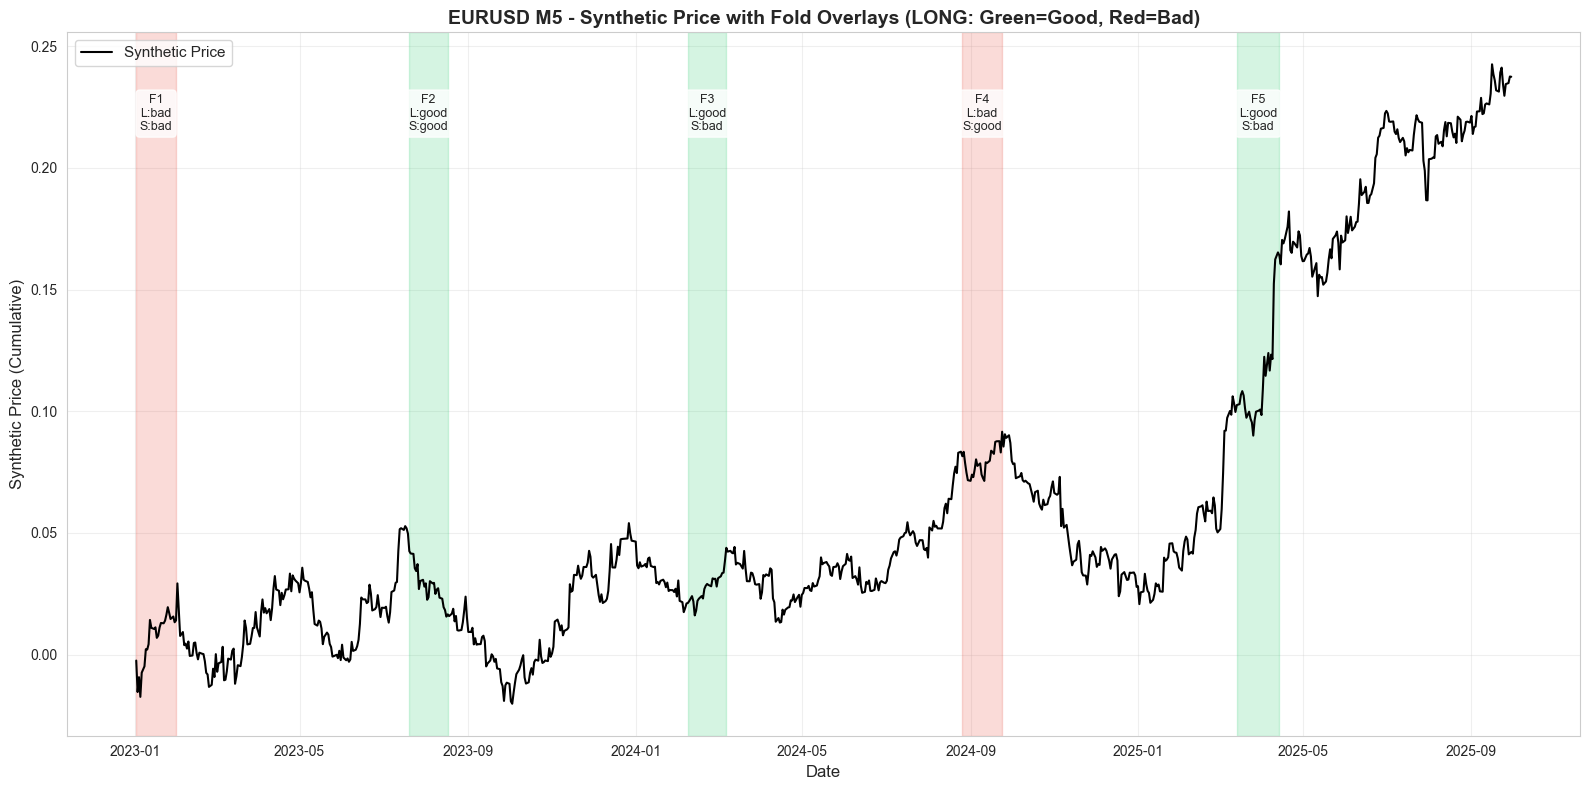

In [5]:
# Create synthetic price from cumsum of bar0_body * atr_m5 (normalized)
df_analysis['synth_return'] = df_analysis['bar0_body'] * df_analysis['atr_m5']
df_analysis['synth_price'] = df_analysis['synth_return'].cumsum()

# Resample to daily for readability
df_daily = df_analysis.groupby(df_analysis['timestamp'].dt.date).agg({
    'synth_price': 'last',
    'fold_num': 'first',
    'long_status': 'first',
    'short_status': 'first',
}).reset_index()

df_daily.rename(columns={'timestamp': 'date'}, inplace=True)
df_daily['date'] = pd.to_datetime(df_daily['date'])

print(f"Daily data: {len(df_daily):,} trading days")

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Plot price
ax.plot(df_daily['date'], df_daily['synth_price'], color='black', linewidth=1.5, label='Synthetic Price')

# Shade folds by LONG status
colors = {'good': '#2ecc71', 'bad': '#e74c3c', 'unknown': '#cccccc'}

for fold_num in range(1, 6):
    fold_data = df_daily[df_daily['fold_num'] == fold_num]
    if len(fold_data) > 0:
        start_date = fold_data['date'].min()
        end_date = fold_data['date'].max()
        
        long_status = fold_data['long_status'].iloc[0]
        short_status = fold_data['short_status'].iloc[0]
        
        color = colors.get(long_status, '#cccccc')
        ax.axvspan(start_date, end_date, alpha=0.2, color=color)
        
        # Add label in middle of fold
        mid_date = start_date + (end_date - start_date) / 2
        y_pos = df_daily['synth_price'].max() * 0.95
        ax.text(mid_date, y_pos, 
               f"F{fold_num}\nL:{long_status}\nS:{short_status}",
               ha='center', va='top', fontsize=9, 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Synthetic Price (Cumulative)', fontsize=12)
ax.set_title('EURUSD M5 - Synthetic Price with Fold Overlays (LONG: Green=Good, Red=Bad)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
output_path = output_dir / 'fold_overview_chart.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

## Cell 6: Eyeball Assessment (Markdown Template)

**Fold 1 (Jan-Mar 2023):**
- Bad LONG, Bad SHORT
- Visual observation: [User to fill in]
- Price trend: [User to fill in]
- Volatility impression: [User to fill in]

**Fold 2 (Mar-May 2023):**
- Good LONG, Good SHORT
- Visual observation: [User to fill in]
- Price trend: [User to fill in]
- Volatility impression: [User to fill in]

**Fold 3 (May-Jul 2023):**
- Good LONG, Bad SHORT
- Visual observation: [User to fill in]
- Price trend: [User to fill in]
- Volatility impression: [User to fill in]

**Fold 4 (Jul-Sep 2023):**
- Bad LONG, Good SHORT
- Visual observation: [User to fill in]
- Price trend: [User to fill in]
- Volatility impression: [User to fill in]

**Fold 5 (Sep 2023 - Sep 2025):**
- Good LONG, Bad SHORT
- Visual observation: [User to fill in]
- Price trend: [User to fill in]
- Volatility impression: [User to fill in]

## Cell 7: Per-Fold Regime Statistics

In [6]:
def regime_stats(df_fold, fold_num):
    """
    Compute comprehensive regime statistics for a fold.
    
    Returns dict with:
    - Volatility: atr_mean, atr_std, atr_p90, bb_width_mean
    - Trend: adx_mean, adx_above_25_pct
    - Direction: bull_aligned_pct, bear_aligned_pct, mixed_pct
    - Persistence: avg_alignment_run, flips_per_1000bar
    - H1 context: h1_slope_mean, h1_slope_std
    - Labels: win_long, loss_long, timeout_long, win_rate_long, win_short, loss_short, timeout_short, win_rate_short
    """
    stats_dict = {'fold': fold_num}
    
    # Volatility metrics
    stats_dict['atr_mean'] = df_fold['atr_m5'].mean()
    stats_dict['atr_std'] = df_fold['atr_m5'].std()
    stats_dict['atr_p90'] = df_fold['atr_m5'].quantile(0.90)
    
    if 'bb_width' in df_fold.columns:
        stats_dict['bb_width_mean'] = df_fold['bb_width'].mean()
    else:
        stats_dict['bb_width_mean'] = np.nan
    
    # Trend metrics (ADX)
    if 'adx_m5' in df_fold.columns:
        stats_dict['adx_mean'] = df_fold['adx_m5'].mean()
        stats_dict['adx_above_25_pct'] = (df_fold['adx_m5'] > 25).sum() / len(df_fold) * 100
    else:
        stats_dict['adx_mean'] = np.nan
        stats_dict['adx_above_25_pct'] = np.nan
    
    # Direction metrics (from alignment score)
    if 'mtf_alignment_score' in df_fold.columns:
        # Score ranges ~[-4, 4]: positive = bull, negative = bear
        alignment = df_fold['mtf_alignment_score']
        bull_mask = alignment >= 3
        bear_mask = alignment <= -3
        mixed_mask = ~(bull_mask | bear_mask)
        
        stats_dict['bull_aligned_pct'] = bull_mask.sum() / len(df_fold) * 100
        stats_dict['bear_aligned_pct'] = bear_mask.sum() / len(df_fold) * 100
        stats_dict['mixed_pct'] = mixed_mask.sum() / len(df_fold) * 100
    else:
        stats_dict['bull_aligned_pct'] = np.nan
        stats_dict['bear_aligned_pct'] = np.nan
        stats_dict['mixed_pct'] = np.nan
    
    # Persistence metrics
    if 'mtf_alignment_duration' in df_fold.columns:
        stats_dict['avg_alignment_run'] = df_fold['mtf_alignment_duration'].abs().mean()
        
        # Count flips
        if 'mtf_alignment_score' in df_fold.columns:
            flips = (df_fold['mtf_alignment_score'].shift(1) * df_fold['mtf_alignment_score'] < 0).sum()
            stats_dict['flips_per_1000bar'] = (flips / len(df_fold)) * 1000
        else:
            stats_dict['flips_per_1000bar'] = np.nan
    else:
        stats_dict['avg_alignment_run'] = np.nan
        stats_dict['flips_per_1000bar'] = np.nan
    
    # H1 context (slope of H1 SMA 200)
    if 'slope_sma_h1_200' in df_fold.columns:
        stats_dict['h1_slope_mean'] = df_fold['slope_sma_h1_200'].mean()
        stats_dict['h1_slope_std'] = df_fold['slope_sma_h1_200'].std()
    else:
        stats_dict['h1_slope_mean'] = np.nan
        stats_dict['h1_slope_std'] = np.nan
    
    # Label statistics (LONG)
    if 'outcome_long' in df_fold.columns:
        long_outcomes = df_fold['outcome_long'].value_counts()
        stats_dict['win_long'] = long_outcomes.get('win', 0)
        stats_dict['loss_long'] = long_outcomes.get('loss', 0)
        stats_dict['timeout_long'] = long_outcomes.get('timeout', 0)
        total_long = stats_dict['win_long'] + stats_dict['loss_long']
        stats_dict['win_rate_long'] = (stats_dict['win_long'] / total_long * 100) if total_long > 0 else np.nan
    else:
        stats_dict['win_long'] = np.nan
        stats_dict['loss_long'] = np.nan
        stats_dict['timeout_long'] = np.nan
        stats_dict['win_rate_long'] = np.nan
    
    # Label statistics (SHORT)
    if 'outcome_short' in df_fold.columns:
        short_outcomes = df_fold['outcome_short'].value_counts()
        stats_dict['win_short'] = short_outcomes.get('win', 0)
        stats_dict['loss_short'] = short_outcomes.get('loss', 0)
        stats_dict['timeout_short'] = short_outcomes.get('timeout', 0)
        total_short = stats_dict['win_short'] + stats_dict['loss_short']
        stats_dict['win_rate_short'] = (stats_dict['win_short'] / total_short * 100) if total_short > 0 else np.nan
    else:
        stats_dict['win_short'] = np.nan
        stats_dict['loss_short'] = np.nan
        stats_dict['timeout_short'] = np.nan
        stats_dict['win_rate_short'] = np.nan
    
    return stats_dict


# Compute stats for each fold
fold_stats_list = []

for fold_num in range(1, 6):
    df_fold = df_analysis[df_analysis['fold_num'] == fold_num]
    if len(df_fold) > 0:
        fold_result = regime_stats(df_fold, fold_num)  # Renamed from 'stats' to avoid collision
        fold_stats_list.append(fold_result)

fold_stats_df = pd.DataFrame(fold_stats_list)

print(f"\nFold Regime Statistics:")
print(fold_stats_df.to_string(index=False))

# Save to CSV
output_path = output_dir / 'fold_regime_stats.csv'
fold_stats_df.to_csv(output_path, index=False)
print(f"\n✓ Saved: {output_path}")


Fold Regime Statistics:


 fold  atr_mean  atr_std  atr_p90  bb_width_mean  adx_mean  adx_above_25_pct  bull_aligned_pct  bear_aligned_pct  mixed_pct  avg_alignment_run  flips_per_1000bar  h1_slope_mean  h1_slope_std  win_long  loss_long  timeout_long  win_rate_long  win_short  loss_short  timeout_short  win_rate_short
    1  0.000476 0.000261 0.000792       4.254779 24.870061         40.505297         42.396088         13.251834  44.352078          52.222820           1.140994       0.000212      0.000227      1990       3708           437      34.924535       1811        4029            295       31.010274
    2  0.000361 0.000204 0.000612       4.628034 24.393305         40.847596          8.590057         49.942950  41.466993          55.590546           1.629992      -0.000138      0.000308      1731       4138           266      29.493951       2026        3828            281       34.608814
    3  0.000252 0.000140 0.000420       4.444713 23.092825         33.545232         42.917685         13.496333  

## Cell 8: Good vs Bad Fold Comparison (LONG Perspective)

In [7]:
# Identify good and bad folds for LONG
good_folds_long = [f for f in fold_status.keys() if fold_status[f]['long'] == 'good']
bad_folds_long = [f for f in fold_status.keys() if fold_status[f]['long'] == 'bad']

print(f"LONG - Good folds: {good_folds_long}, Bad folds: {bad_folds_long}")

# Filter data
df_good_long = df_analysis[df_analysis['fold_num'].isin(good_folds_long)]
df_bad_long = df_analysis[df_analysis['fold_num'].isin(bad_folds_long)]

print(f"Good LONG folds: {len(df_good_long):,} bars")
print(f"Bad LONG folds: {len(df_bad_long):,} bars")

# Compute mean stats for good vs bad
comparison_metrics = [
    'atr_m5', 'adx_m5', 'bb_width', 'mtf_alignment_score', 'mtf_alignment_duration',
    'slope_sma_h1_200', 'rsi_m5', 'dist_sma_m5_200', 'di_plus_m5', 'di_minus_m5'
]

available_metrics = [m for m in comparison_metrics if m in df_analysis.columns]

comparison_long = []
for metric in available_metrics:
    good_mean = df_good_long[metric].mean()
    bad_mean = df_bad_long[metric].mean()
    
    if good_mean != 0:
        pct_diff = (bad_mean - good_mean) / abs(good_mean) * 100
    else:
        pct_diff = 0
    
    comparison_long.append({
        'metric': metric,
        'good_mean': good_mean,
        'bad_mean': bad_mean,
        'pct_diff': pct_diff,
        'abs_diff': bad_mean - good_mean
    })

comparison_long_df = pd.DataFrame(comparison_long).sort_values('pct_diff', key=abs, ascending=False)

print(f"\nGood vs Bad Folds - LONG Perspective (sorted by largest % difference):")
print(comparison_long_df.to_string(index=False))

# Save to CSV
output_path = output_dir / 'long_good_vs_bad_comparison.csv'
comparison_long_df.to_csv(output_path, index=False)
print(f"\n✓ Saved: {output_path}")

LONG - Good folds: [2, 3, 5], Bad folds: [1, 4]
Good LONG folds: 18,405 bars
Bad LONG folds: 12,270 bars

Good vs Bad Folds - LONG Perspective (sorted by largest % difference):
                metric  good_mean  bad_mean    pct_diff  abs_diff
   mtf_alignment_score  -0.044444  0.608313 1468.704156  0.652757
mtf_alignment_duration  -1.513610 11.501141  859.848159 13.014751
       dist_sma_m5_200  -0.185990  0.331431  278.197761  0.517421
      slope_sma_h1_200   0.000038  0.000128  237.515838  0.000090
                atr_m5   0.000409  0.000383   -6.409024 -0.000026
              bb_width   4.548104  4.375073   -3.804464 -0.173031
            di_plus_m5  22.497437 21.879792   -2.745405 -0.617646
           di_minus_m5  22.171761 21.754263   -1.883018 -0.417498
                adx_m5  24.083242 24.465342    1.586578  0.382099
                rsi_m5  50.373417 50.542858    0.336369  0.169441

✓ Saved: ..\outputs\phase2_fold_diagnosis\long_good_vs_bad_comparison.csv


## Cell 9: Good vs Bad Fold Comparison (SHORT Perspective)

In [8]:
# Identify good and bad folds for SHORT
good_folds_short = [f for f in fold_status.keys() if fold_status[f]['short'] == 'good']
bad_folds_short = [f for f in fold_status.keys() if fold_status[f]['short'] == 'bad']

print(f"SHORT - Good folds: {good_folds_short}, Bad folds: {bad_folds_short}")

# Filter data
df_good_short = df_analysis[df_analysis['fold_num'].isin(good_folds_short)]
df_bad_short = df_analysis[df_analysis['fold_num'].isin(bad_folds_short)]

print(f"Good SHORT folds: {len(df_good_short):,} bars")
print(f"Bad SHORT folds: {len(df_bad_short):,} bars")

# Compute mean stats for good vs bad
comparison_short = []
for metric in available_metrics:
    good_mean = df_good_short[metric].mean()
    bad_mean = df_bad_short[metric].mean()
    
    if good_mean != 0:
        pct_diff = (bad_mean - good_mean) / abs(good_mean) * 100
    else:
        pct_diff = 0
    
    comparison_short.append({
        'metric': metric,
        'good_mean': good_mean,
        'bad_mean': bad_mean,
        'pct_diff': pct_diff,
        'abs_diff': bad_mean - good_mean
    })

comparison_short_df = pd.DataFrame(comparison_short).sort_values('pct_diff', key=abs, ascending=False)

print(f"\nGood vs Bad Folds - SHORT Perspective (sorted by largest % difference):")
print(comparison_short_df.to_string(index=False))

# Save to CSV
output_path = output_dir / 'short_good_vs_bad_comparison.csv'
comparison_short_df.to_csv(output_path, index=False)
print(f"\n✓ Saved: {output_path}")

SHORT - Good folds: [2, 4], Bad folds: [1, 3, 5]
Good SHORT folds: 12,270 bars
Bad SHORT folds: 18,405 bars

Good vs Bad Folds - SHORT Perspective (sorted by largest % difference):
                metric  good_mean  bad_mean   pct_diff  abs_diff
      slope_sma_h1_200  -0.000047  0.000154 428.245202  0.000201
   mtf_alignment_score  -0.913121  0.969845 206.212067  1.882967
mtf_alignment_duration -23.183211 21.609291 193.210949 44.792502
       dist_sma_m5_200  -1.178404  0.820566 169.633679  1.998970
                atr_m5   0.000326  0.000447  37.282281  0.000121
           di_minus_m5  22.567598 21.629538  -4.156668 -0.938060
              bb_width   4.561700  4.423686  -3.025511 -0.138015
                rsi_m5  49.770480 50.888336   2.246022  1.117856
            di_plus_m5  22.056095 22.379902   1.468105  0.323807
                adx_m5  24.226964 24.242161   0.062730  0.015197

✓ Saved: ..\outputs\phase2_fold_diagnosis\short_good_vs_bad_comparison.csv


## Cell 10: Statistical Significance Testing (Mann-Whitney U)

In [9]:
# Key features for statistical testing
test_features = [
    'atr_m5', 'adx_m5', 'bb_width', 'mtf_alignment_score', 'mtf_alignment_duration',
    'slope_sma_h1_200', 'rsi_m5'
]

available_test_features = [f for f in test_features if f in df_analysis.columns]

print("Mann-Whitney U Test Results (Good vs Bad Folds)\n")
print("="*80)

# LONG perspective
print("\nLONG Perspective:")
print("-"*80)

mw_results_long = []
for feature in available_test_features:
    good_data = df_good_long[feature].dropna()
    bad_data = df_bad_long[feature].dropna()
    
    if len(good_data) > 0 and len(bad_data) > 0:
        statistic, p_value = stats.mannwhitneyu(good_data, bad_data, alternative='two-sided')
        significant = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        
        mw_results_long.append({
            'feature': feature,
            'good_mean': good_data.mean(),
            'bad_mean': bad_data.mean(),
            'p_value': p_value,
            'significant': significant
        })
        
        print(f"{feature:30s}: p={p_value:.6f} {significant}")

mw_results_long_df = pd.DataFrame(mw_results_long).sort_values('p_value')

# SHORT perspective
print("\nSHORT Perspective:")
print("-"*80)

mw_results_short = []
for feature in available_test_features:
    good_data = df_good_short[feature].dropna()
    bad_data = df_bad_short[feature].dropna()
    
    if len(good_data) > 0 and len(bad_data) > 0:
        statistic, p_value = stats.mannwhitneyu(good_data, bad_data, alternative='two-sided')
        significant = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        
        mw_results_short.append({
            'feature': feature,
            'good_mean': good_data.mean(),
            'bad_mean': bad_data.mean(),
            'p_value': p_value,
            'significant': significant
        })
        
        print(f"{feature:30s}: p={p_value:.6f} {significant}")

mw_results_short_df = pd.DataFrame(mw_results_short).sort_values('p_value')

print("\n" + "="*80)
print("Significance levels: * p<0.05, ** p<0.01, *** p<0.001")

Mann-Whitney U Test Results (Good vs Bad Folds)


LONG Perspective:
--------------------------------------------------------------------------------
atr_m5                        : p=0.001604 **
adx_m5                        : p=0.379728 
bb_width                      : p=0.000000 ***
mtf_alignment_score           : p=0.000000 ***
mtf_alignment_duration        : p=0.000000 ***
slope_sma_h1_200              : p=0.000000 ***
rsi_m5                        : p=0.090598 

SHORT Perspective:
--------------------------------------------------------------------------------
atr_m5                        : p=0.000000 ***
adx_m5                        : p=0.249256 
bb_width                      : p=0.000010 ***
mtf_alignment_score           : p=0.000000 ***
mtf_alignment_duration        : p=0.000000 ***
slope_sma_h1_200              : p=0.000000 ***
rsi_m5                        : p=0.000000 ***

Significance levels: * p<0.05, ** p<0.01, *** p<0.001


## Cell 11: Distribution Overlays (LONG: Good vs Bad)

✓ Saved: ..\outputs\phase2_fold_diagnosis\feature_distributions_long_good_vs_bad.png


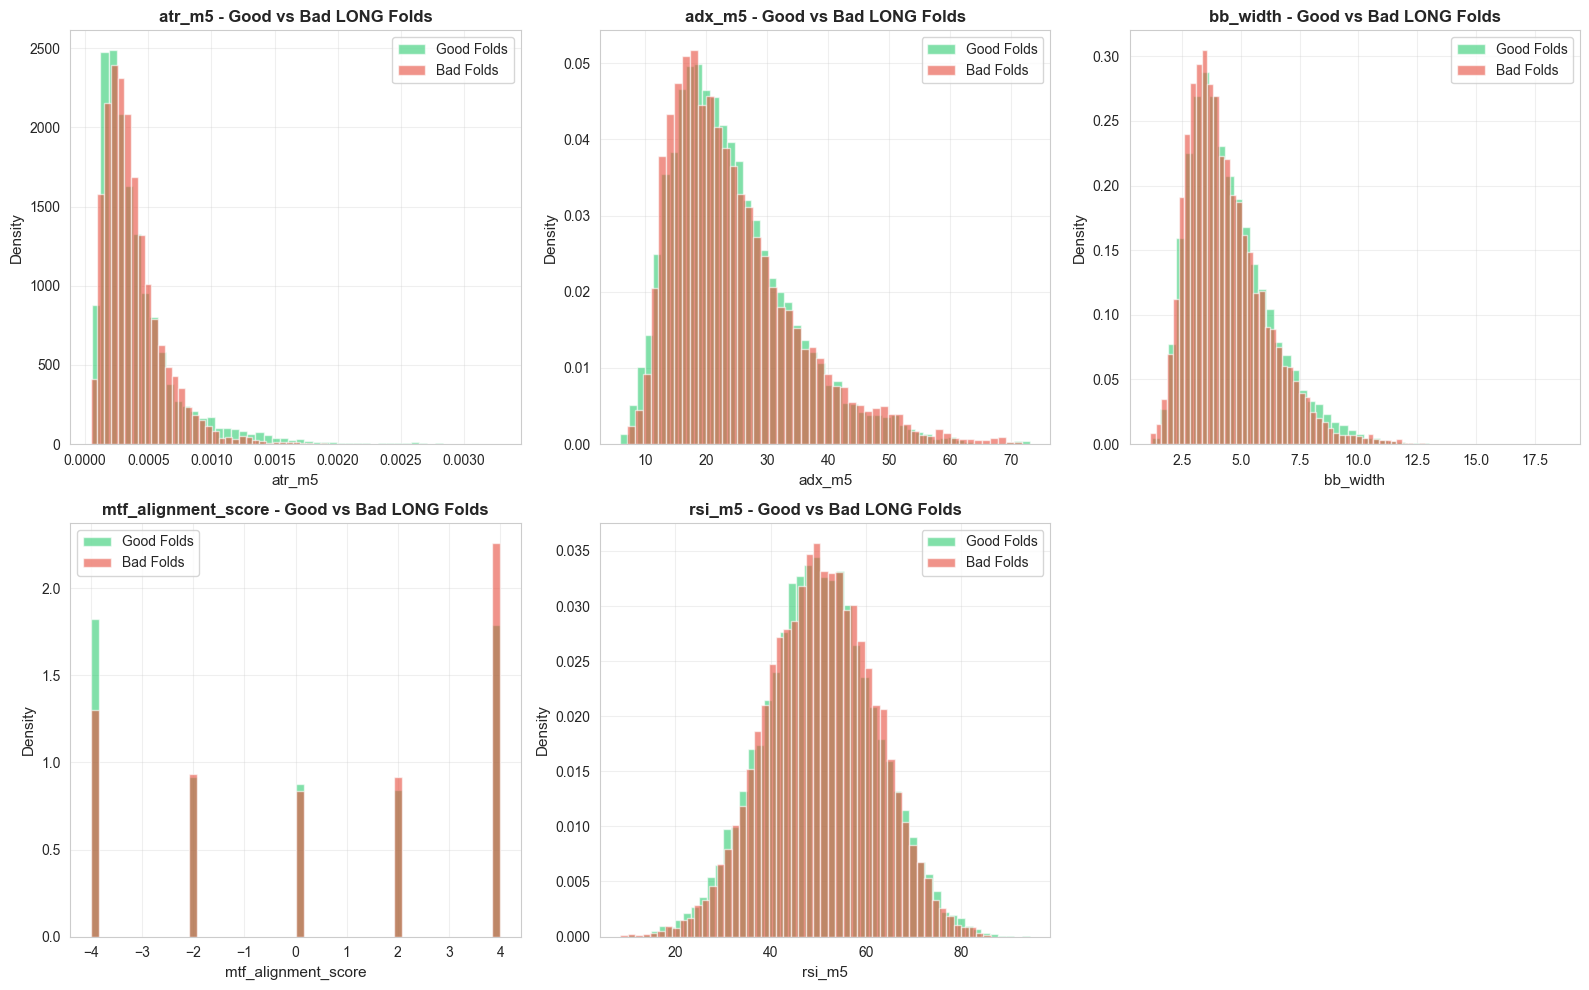

In [10]:
# Plot distributions for key features (LONG perspective)
key_features_plot = ['atr_m5', 'adx_m5', 'bb_width', 'mtf_alignment_score', 'rsi_m5']
key_features_plot = [f for f in key_features_plot if f in df_analysis.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features_plot):
    ax = axes[idx]
    
    good_data = df_good_long[feature].dropna()
    bad_data = df_bad_long[feature].dropna()
    
    # Plot histograms with density
    ax.hist(good_data, bins=50, alpha=0.6, label='Good Folds', color='#2ecc71', density=True)
    ax.hist(bad_data, bins=50, alpha=0.6, label='Bad Folds', color='#e74c3c', density=True)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{feature} - Good vs Bad LONG Folds', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
if len(key_features_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
output_path = output_dir / 'feature_distributions_long_good_vs_bad.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

## Cell 12: Distribution Overlays (SHORT: Good vs Bad)

✓ Saved: ..\outputs\phase2_fold_diagnosis\feature_distributions_short_good_vs_bad.png


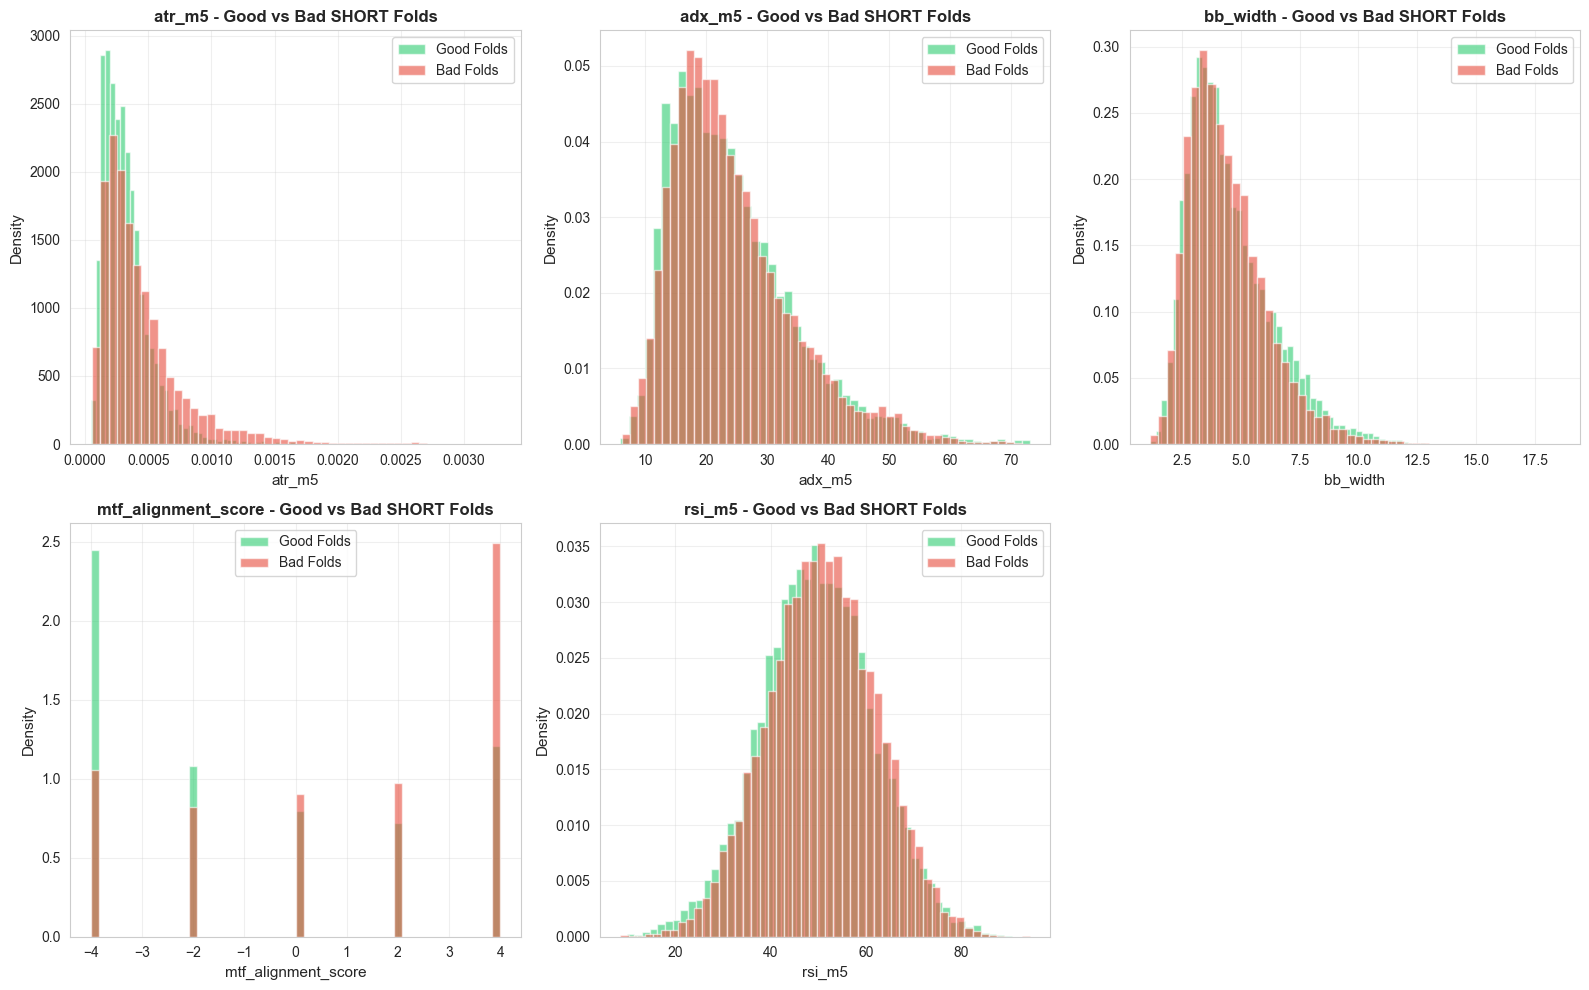

In [11]:
# Plot distributions for key features (SHORT perspective)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features_plot):
    ax = axes[idx]
    
    good_data = df_good_short[feature].dropna()
    bad_data = df_bad_short[feature].dropna()
    
    # Plot histograms with density
    ax.hist(good_data, bins=50, alpha=0.6, label='Good Folds', color='#2ecc71', density=True)
    ax.hist(bad_data, bins=50, alpha=0.6, label='Bad Folds', color='#e74c3c', density=True)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{feature} - Good vs Bad SHORT Folds', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
if len(key_features_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
output_path = output_dir / 'feature_distributions_short_good_vs_bad.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

## Cell 13: Equity Curve with Regime Markers (Placeholder)

**Note:** This cell requires model predictions from the trained models. The code template is provided but commented out for now.

When model predictions are available, uncomment and fill in the following:
1. Load trained LONG and SHORT models
2. Generate predictions on fold test sets
3. Calculate equity curves per fold
4. Plot with regime overlays (volatility, trend, alignment periods)

In [12]:
# Template for future implementation:
# from joblib import load
# model_long = load('../models/eurusd_long_v1.joblib')
# model_short = load('../models/eurusd_short_v1.joblib')
# y_pred_long = model_long.predict(X_long)
# y_pred_short = model_short.predict(X_short)
# [Calculate and plot equity curves with regime markers]

print("Placeholder for equity curve analysis with regime markers.")
print("Requires trained model predictions - see commented template above.")

Placeholder for equity curve analysis with regime markers.
Requires trained model predictions - see commented template above.


## Cell 14: Diagnosis Summary

**Data Summary:**
- Train/CV period: Jan 2023 - Sep 2025 (204,105 bars, ~2.75 years)
- Asset: EURUSD M5
- Folds: 5 (walk-forward, ~20% test size each)
- Reference threshold: 0.55 (from Phase 2 results)

**Fold Performance (Phase 2 at threshold 0.55):**

| Fold | LONG | SHORT | Status |
|------|------|-------|--------|
| 1    | Bad  | Bad   | Consistently poor regime |
| 2    | Good | Good  | Ideal regime for both directions |
| 3    | Good | Bad   | Bull-biased regime |
| 4    | Bad  | Good  | Bear-biased regime |
| 5    | Good | Bad   | Bull-biased regime |

---

### Key Findings

**From Regime Statistics & Statistical Tests:**

[User to fill in based on fold_regime_stats.csv and Mann-Whitney results]

1. **Volatility characteristics:**
   - Good vs Bad folds differ in ATR? [Yes/No]
   - Bollinger Band width patterns? [Fill in]

2. **Trend strength (ADX):**
   - Strong trends favor [LONG/SHORT/Both/Neither]? [Fill in]
   - % bars with ADX > 25? [Fill in]

3. **Directional alignment:**
   - Bull-aligned bars: Good LONG folds vs Bad LONG folds [Fill in]
   - Bear-aligned bars: Good SHORT folds vs Bad SHORT folds [Fill in]
   - Mixed regime impact? [Fill in]

4. **Persistence:**
   - Alignment run duration differences? [Fill in]
   - Flip frequency impact? [Fill in]

5. **H1 Context:**
   - H1 SMA 200 slope correlation with fold performance? [Fill in]

---

### Top 3 Regime Features (Ranked by Statistical Significance)

**LONG Perspective:**
1. [Feature name] - p-value: [X], difference: [Y]%
2. [Feature name] - p-value: [X], difference: [Y]%
3. [Feature name] - p-value: [X], difference: [Y]%

**SHORT Perspective:**
1. [Feature name] - p-value: [X], difference: [Y]%
2. [Feature name] - p-value: [X], difference: [Y]%
3. [Feature name] - p-value: [X], difference: [Y]%

---

### Verdict

**Root Cause of Fold Failures:**

[User to write 2-3 sentence conclusion based on analysis]

**Strategy-Regime Mismatch:** 
- LONG model struggles with [regime type, e.g., "choppy, low-trend markets"]
- SHORT model struggles with [regime type, e.g., "strong uptrends with persistent bull alignment"]
- Fold 1 is problematic because [fill in reason]

---

### Next Steps

1. **Regime Detection:** Implement real-time regime classification to switch models or thresholds
2. **Ensemble Approach:** Weight predictions based on current regime characteristics
3. **Separate Models:** Train fold-specific or regime-specific models
4. **Feature Engineering:** Add regime interaction terms to capture non-linear relationships
5. **Dynamic Thresholds:** Adjust decision thresholds based on fold-specific optimal levels


## Cell 15: Session Summary

In [13]:
print("\n" + "="*80)
print("PHASE 2 FOLD REGIME DIAGNOSIS - ANALYSIS COMPLETE")
print("="*80)

print(f"\nOutputs saved to: {output_dir.absolute()}")
print("\nGenerated files:")
for file in sorted(output_dir.glob('*')):
    if file.is_file():
        size_kb = file.stat().st_size / 1024
        print(f"  - {file.name:<40s} ({size_kb:>8.1f} KB)")

print(f"\nAnalysis timestamp: {datetime.now().isoformat()}")
print("\nNext step: Review diagnosis summary in Cell 14 and plan Phase 3 actions.")


PHASE 2 FOLD REGIME DIAGNOSIS - ANALYSIS COMPLETE

Outputs saved to: D:\JCAMP_FxScalper_ML\notebooks\..\outputs\phase2_fold_diagnosis

Generated files:
  - feature_distributions_long_good_vs_bad.png (   144.8 KB)
  - feature_distributions_short_good_vs_bad.png (   147.7 KB)
  - fold_overview_chart.png                  (   145.9 KB)
  - fold_regime_stats.csv                    (     1.8 KB)
  - long_good_vs_bad_comparison.csv          (     1.0 KB)
  - README.md                                (     7.4 KB)
  - short_good_vs_bad_comparison.csv         (     0.9 KB)

Analysis timestamp: 2026-04-15T21:37:31.388004

Next step: Review diagnosis summary in Cell 14 and plan Phase 3 actions.
